In [39]:
from google.colab import files

uploaded = files.upload()

Saving insurance.csv to insurance (2).csv


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv("insurance.csv")

print(df.shape)

df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [42]:
X = df[['age']].values

y = df['charges'].values.reshape(-1,1)

In [43]:
X_train = X[:700]
y_train = y[:700]

X_val = X[700:800]
y_val = y[700:800]

X_test = X[800:1000]
y_test = y[800:1000]

In [44]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(700, 1)
(100, 1)
(200, 1)


In [45]:
X_train_b = np.c_[np.ones((700,1)), X_train]

X_val_b = np.c_[np.ones((100,1)), X_val]

X_test_b = np.c_[np.ones((200,1)), X_test]

In [46]:
theta = np.zeros((2,1))

learning_rate = 0.0001

iterations = 5000

In [47]:
m = len(X_train)

cost_history = []

for i in range(iterations):

    # Prediction
    predictions = X_train_b @ theta

    # Error
    error = predictions - y_train

    # Gradient
    gradient = (1/m) * (X_train_b.T @ error)

    # Update theta
    theta = theta - learning_rate * gradient

    # Cost
    cost = (1/(2*m)) * np.sum(error**2)

    cost_history.append(cost)

    print("="*60)
    print("Iteration:", i+1)

    print("\nTheta:")
    print(theta)

    print("\nFirst 5 Predictions:")
    print(predictions[:5])

    print("\nFirst 5 Errors:")
    print(error[:5])

    print("\nGradient:")
    print(gradient)

    print("\nCost:")
    print(cost)

Streaming output truncated to the last 5000 lines.
[[-240.75433903]
 [   5.36741183]]

Cost:
67100740.45670957
Iteration: 4816

Theta:
[[126.63582956]
 [328.80174812]]

First 5 Predictions:
[[ 6373.85516657]
 [ 6045.05288172]
 [ 9333.07573023]
 [10977.08715448]
 [10648.28486963]]

First 5 Errors:
[[-10511.06883343]
 [  4319.50058172]
 [  4883.61373023]
 [-11007.38345552]
 [  6781.42966963]]

Gradient:
[[-240.75154538]
 [   5.36734955]]

Cost:
67100734.65759713
Iteration: 4817

Theta:
[[126.65990443]
 [328.80121139]]

First 5 Predictions:
[[ 6373.86904376]
 [ 6045.06729565]
 [ 9333.08477681]
 [10977.09351739]
 [10648.29176927]]

First 5 Errors:
[[-10511.05495624]
 [  4319.51499565]
 [  4883.62277681]
 [-11007.37709261]
 [  6781.43656927]]

Gradient:
[[-240.74875177]
 [   5.36728727]]

Cost:
67100728.85861927
Iteration: 4818

Theta:
[[126.68397903]
 [328.80067466]]

First 5 Predictions:
[[ 6373.88292079]
 [ 6045.0817094 ]
 [ 9333.09382328]
 [10977.09988021]
 [10648.29866883]]

First 5 Er

In [48]:
print(theta)

[[131.06090663]
 [328.70309481]]


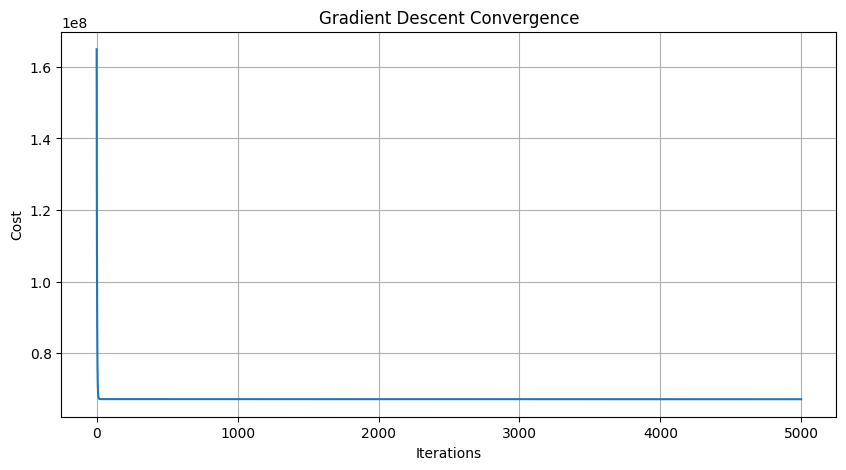

In [49]:
plt.figure(figsize=(10,5))

plt.plot(cost_history)

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.title("Gradient Descent Convergence")

plt.grid(True)

plt.show()

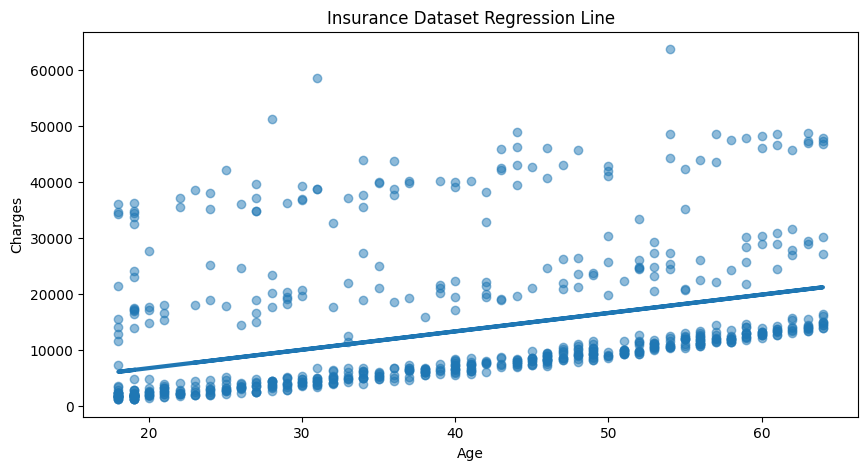

In [50]:
plt.figure(figsize=(10,5))

plt.scatter(
    X_train,
    y_train,
    alpha=0.5
)

plt.plot(
    X_train,
    X_train_b @ theta,
    linewidth=3
)

plt.xlabel("Age")

plt.ylabel("Charges")

plt.title("Insurance Dataset Regression Line")

plt.show()

In [51]:
theta_normal = np.linalg.inv(
    X_train_b.T @ X_train_b
) @ X_train_b.T @ y_train

print(theta_normal)

[[2201.39071944]
 [ 282.54686443]]


In [52]:
print("Gradient Descent Theta")
print(theta)

print("\nNormal Equation Theta")
print(theta_normal)

Gradient Descent Theta
[[131.06090663]
 [328.70309481]]

Normal Equation Theta
[[2201.39071944]
 [ 282.54686443]]


In [53]:
val_pred = X_val_b @ theta

val_mse = np.mean(
    (val_pred - y_val)**2
)

print("Validation MSE")

print(val_mse)

Validation MSE
99898673.32878268


In [54]:
test_pred = X_test_b @ theta

test_mse = np.mean(
    (test_pred - y_test)**2
)

print("Test MSE")

print(test_mse)

Test MSE
121896943.2860194


In [55]:
comparison = pd.DataFrame({

    "Actual":
    y_test.flatten(),

    "Predicted":
    test_pred.flatten()

})

comparison.head(20)

,Actual,Predicted
0,7046.72220,13936.590889
1,14313.84630,21168.058975
2,2103.08000,7033.825898
3,38792.68560,6047.716613
4,1815.87590,7691.232087
5,7731.85785,14922.700173
6,28476.73499,13279.184699
7,2136.88225,6376.419708
8,1131.50660,6047.716613
9,3309.79260,8348.638277


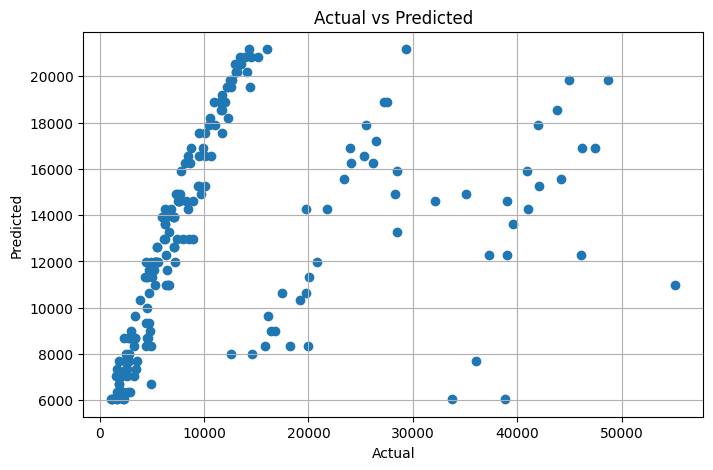

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    test_pred
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

In [57]:
new_age = np.array([
    [25],
    [30],
    [35],
    [40],
    [50]
])

new_X = np.c_[

    np.ones((5,1)),
    new_age

]

new_pred = new_X @ theta

result = pd.DataFrame({

    "Age":
    new_age.flatten(),

    "Predicted Charges":
    new_pred.flatten()

})

print(result)

   Age  Predicted Charges
0   25        8348.638277
1   30        9992.153751
2   35       11635.669225
3   40       13279.184699
4   50       16566.215647
